# A4 — Robust Scaling Ingredients

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

আমাদের কাছে একটি dataset আছে:

$$y = [5, 6, 6, 7, 50]$$

চারটি জিনিস বের করতে হবে — কিন্তু এখনই scale করতে হবে না:

| বের করতে হবে | কী? |
|---|---|
| **Median** | মাঝের মান |
| **Q1** | 25th percentile — নিচের অর্ধেকের মধ্যমান |
| **Q3** | 75th percentile — উপরের অর্ধেকের মধ্যমান |
| **IQR** | $Q3 - Q1$ — মাঝের 50% data-র range |

> **50** স্পষ্টতই একটি **outlier** — এই problem-এর মূল শিক্ষা হলো দেখা যে median ও IQR এই outlier-কে কীভাবে ignore করে।


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- **Median, Q1, Q3, IQR** হাতে হিসাব করার নিয়ম পাকা হবে।
- Outlier **mean ও range-কে কতটা বিকৃত করে** — কিন্তু median ও IQR-কে করে না — সেটা সংখ্যা দিয়ে দেখব।
- Robust Scaling-এর **"ingredients"** কীভাবে বের করতে হয় সেটা বুঝব — পরবর্তী ধাপে এই মানগুলো দিয়েই scale করা হবে।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

### Median কেন Mean-এর চেয়ে ভালো (outlier থাকলে)?

| | Mean | Median |
|---|---|---|
| **হিসাব** | সব মান যোগ করে N দিয়ে ভাগ | sorted list-এর মাঝের মান |
| **Outlier-এ প্রভাব** | outlier টেনে নেয় | outlier উপেক্ষা করে |
| **y = [5,6,6,7,50]** | $(5+6+6+7+50)/5 = 14.8$ | মাঝের মান = **6** |

Mean = 14.8, অথচ 4টি মান 5–7-এর মধ্যে! Median = 6 — এটা data-কে অনেক ভালো represent করে।

### Q1, Q3, IQR বের করার নিয়ম:

**Sorted data:** $[5, 6, 6, 7, 50]$

- **Median** = মাঝের (3rd) মান = **6**
- **Q1** = নিচের অর্ধেক $[5, 6]$-এর median = $(5+6)/2 = 5.5$
- **Q3** = উপরের অর্ধেক $[7, 50]$-এর median = $(7+50)/2 = 28.5$
- **IQR** = $Q3 - Q1 = 28.5 - 5.5 = 23$

> ⚠️ **NumPy/sklearn** Q1 ও Q3 বের করে **percentile interpolation** দিয়ে — হাতের হিসাবের সাথে সামান্য পার্থক্য থাকতে পারে। নিচে দুটোই দেখানো হবে।


---

## 🛠️ Problem Solve করার Approach

**Step 1:** Data define করা ও outlier চিহ্নিত করা।

**Step 2:** Median হাতে হিসাব করা, তারপর code verify।

**Step 3:** Q1 ও Q3 হাতে হিসাব করা, তারপর code verify।

**Step 4:** IQR বের করা।

**Step 5:** Mean vs Median তুলনা করে outlier-এর প্রভাব দেখা।


## Step 1: Data Define করা

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y = np.array([5, 6, 6, 7, 50], dtype=float)
y_sorted = np.sort(y)

print(f"y         : {y}")
print(f"y (sorted): {y_sorted}")
print(f"N         : {len(y)}")
print(f"Outlier   : 50 (clearly far from the rest: 5-7)")


y         : [ 5.  6.  6.  7. 50.]
y (sorted): [ 5.  6.  6.  7. 50.]
N         : 5
Outlier   : 50 (clearly far from the rest: 5-7)


`np.sort()` → ascending order-এ sort করে। Median ও quartile বের করতে sorted data লাগে।
50 স্পষ্টতই outlier — বাকি চারটি মান 5–7-এর মধ্যে।


---

## Step 2: Median বের করা

**Sorted:** $[5, 6, \mathbf{6}, 7, 50]$

N = 5 (বিজোড়) → মাঝের index = $(5+1)/2 = 3$rd মান

$$\text{Median} = \mathbf{6}$$


In [2]:
median_manual = y_sorted[len(y) // 2]      # middle index for odd N
median_numpy  = np.median(y)

print(f"Sorted array    : {y_sorted}")
print(f"Middle index    : {len(y) // 2}  (0-based)")
print(f"Manual median   : {median_manual}")
print(f"NumPy  median   : {median_numpy}")
print(f"Match           : {median_manual == median_numpy}")


Sorted array    : [ 5.  6.  6.  7. 50.]
Middle index    : 2  (0-based)
Manual median   : 6.0
NumPy  median   : 6.0
Match           : True


`len(y) // 2` → integer division দিয়ে মাঝের index বের করা (0-based, তাই index=2 মানে 3rd মান)।
`np.median()` → NumPy-র built-in median function। N বিজোড় হলে মাঝের মান, জোড় হলে মাঝের দুটোর গড় নেয়।


---

## Step 3: Q1 ও Q3 বের করা

**Sorted:** $[5, 6, 6, 7, 50]$

Median (6) বাদ দিয়ে:
- **নিচের অর্ধেক:** $[5, 6]$ → Q1 = $(5+6)/2 = \mathbf{5.5}$
- **উপরের অর্ধেক:** $[7, 50]$ → Q3 = $(7+50)/2 = \mathbf{28.5}$


In [5]:
# Hand calculation
lower_half = y_sorted[:len(y) // 2]         # [5, 6]
upper_half = y_sorted[len(y) // 2 + 1:]     # [7, 50]

Q1_manual = np.median(lower_half)
Q3_manual = np.median(upper_half)

# NumPy percentile (may differ slightly due to interpolation method)
Q1_numpy = np.percentile(y, 25)
Q3_numpy = np.percentile(y, 75)

print(f"Lower half       : {lower_half}  → Q1 = {Q1_manual}")
print(f"Upper half       : {upper_half}  → Q3 = {Q3_manual}")
print()
print(f"Manual  Q1 = {Q1_manual},  Q3 = {Q3_manual}")
print(f"NumPy   Q1 = {Q1_numpy},   Q3 = {Q3_numpy}")


Lower half       : [5. 6.]  → Q1 = 5.5
Upper half       : [ 7. 50.]  → Q3 = 28.5

Manual  Q1 = 5.5,  Q3 = 28.5
NumPy   Q1 = 6.0,   Q3 = 7.0


* `y_sorted[:len(y)//2]` → sorted array-এর প্রথম অর্ধেক (নিচের half)।
* `y_sorted[len(y)//2 + 1:]` → median-এর পরের অর্ধেক (উপরের half)।
* `np.percentile(y, 25)` → NumPy interpolation ব্যবহার করে — হাতের হিসাবের সাথে সামান্য পার্থক্য স্বাভাবিক।

# Manually calculate করা result আর NumPy দিয়ে calculate করা result-এ এত বেধড়ক পার্থক্য হলো কীভাবে? এর কারণটাই বা কী?

এটা **Q1 ও Q3 বের করার পদ্ধতির পার্থক্য** থেকে হয়েছে।

$y = [5, 6, 6, 7, 50]$ — এখানে N=5, বিজোড়।

**হাতের হিসাবে** median বাদ দিয়ে দুই ভাগ করা হয়েছে:
- Lower half = $[5, 6]$ → Q1 = 5.5
- Upper half = $[7, 50]$ → Q3 = 28.5

**NumPy `np.percentile()`** অন্যভাবে কাজ করে। এটি data-কে ভাগ না করে সরাসরি **linear interpolation** ব্যবহার করে।

NumPy ভাবে: "25th percentile মানে হলো sorted array-এর 25% position।" N=5 হলে সেই position হয় index 1 (দ্বিতীয় মান) → **Q1 = 6.0**। একইভাবে 75th percentile → index 3 → **Q3 = 7.0**।

## কোনটা ঠিক?

দুটোই তাদের নিজস্ব পদ্ধতিতে ঠিক। **Q1 ও Q3 বের করার কোনো একক universally agreed পদ্ধতি নেই** — textbook-এ যেটা শেখানো হয় (median দিয়ে ভাগ করা) আর software-এ যেটা ব্যবহার হয় (interpolation) এই দুটো প্রায়ই আলাদা result দেয়।

Robust Scaler নিজেও NumPy-র percentile ব্যবহার করে, তাই **sklearn-এর সাথে মেলাতে চাইলে `np.percentile()`-ই সঠিক।**

হাতের হিসাব শুধু **concept বোঝার জন্য** — exam বা assignment-এ textbook পদ্ধতি (median দিয়ে ভাগ করা) চাইলে হাতের হিসাবই দিতে হবে।

---

## Step 4: IQR বের করা

$$\text{IQR} = Q3 - Q1 = 28.5 - 5.5 = \mathbf{23}$$

IQR মানে হলো মাঝের **50% data** কতটুকু range-এর মধ্যে আছে।


In [9]:
IQR_manual = Q3_manual - Q1_manual
IQR_numpy  = Q3_numpy  - Q1_numpy

print(f"Manual IQR : Q3({Q3_manual}) - Q1({Q1_manual}) = {IQR_manual}")
print(f"NumPy  IQR : Q3({Q3_numpy})  - Q1({Q1_numpy})  = {IQR_numpy}")
print()
print("── Summary (Manual) ──")
summary = pd.DataFrame({
    'Statistic': ['Median', 'Q1', 'Q3', 'IQR'],
    'Value':     [median_manual, Q1_manual, Q3_manual, IQR_manual]
})
print(summary.to_string(index=False))


Manual IQR : Q3(28.5) - Q1(5.5) = 23.0
NumPy  IQR : Q3(7.0)  - Q1(6.0)  = 1.0

── Summary (Manual) ──
Statistic  Value
   Median    6.0
       Q1    5.5
       Q3   28.5
      IQR   23.0


`Q3_manual - Q1_manual` → সরল বিয়োগ।
Summary table-এ Robust Scaling-এর চারটি ingredient একসাথে দেখা যাচ্ছে।
এই মানগুলোই Robust Scaler formula-তে ব্যবহার হয়: $x' = (x - \text{median}) / \text{IQR}$


---

## Step 5: Outlier-এর প্রভাব — Mean vs Median তুলনা


In [10]:
mean_val   = np.mean(y)
median_val = np.median(y)
range_val  = y.max() - y.min()

print(f"Mean   : {mean_val:.1f}  ← outlier (50) টেনে উপরে নিয়েছে")
print(f"Median : {median_val:.1f}   ← outlier সত্ত্বেও data-কে সঠিক represent করছে")
print(f"Range  : {range_val:.1f}  ← outlier-এর কারণে বিশাল")
print(f"IQR    : {IQR_manual:.1f}   ← শুধু মাঝের 50% দেখছে, outlier উপেক্ষিত")
print()
print("4 out of 5 values are between 5 and 7.")
print(f"Mean ({mean_val}) does NOT represent this — Median ({median_val}) does.")


Mean   : 14.8  ← outlier (50) টেনে উপরে নিয়েছে
Median : 6.0   ← outlier সত্ত্বেও data-কে সঠিক represent করছে
Range  : 45.0  ← outlier-এর কারণে বিশাল
IQR    : 23.0   ← শুধু মাঝের 50% দেখছে, outlier উপেক্ষিত

4 out of 5 values are between 5 and 7.
Mean (14.8) does NOT represent this — Median (6.0) does.


**বিশ্লেষণ:**

| | Outlier-এ প্রভাবিত? | y=[5,6,6,7,50]-এ মান |
|---|---|---|
| **Mean** | ✅ হ্যাঁ — outlier টেনে নেয় | 14.8 — misleading |
| **Median** | ❌ না — মাঝের মান নেয় | 6 — সঠিক |
| **Range** | ✅ হ্যাঁ — max-min ব্যবহার করে | 45 — misleading |
| **IQR** | ❌ না — মাঝের 50% দেখে | 23 — robust |

এই কারণেই Robust Scaler **median ও IQR** ব্যবহার করে — outlier থাকলেও scaling বিকৃত হয় না।


## Bonus: Visual — Outlier-এর প্রভাব দেখা

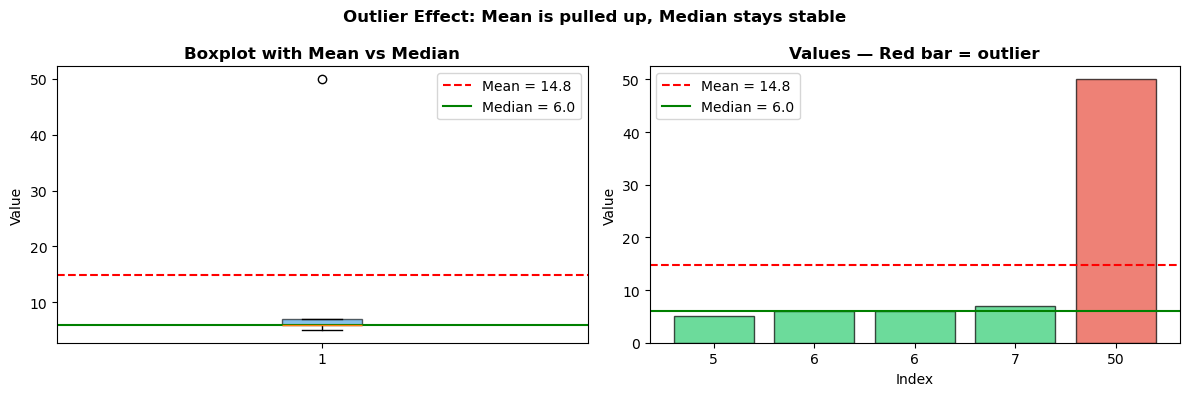

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
axes[0].boxplot(y, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[0].axhline(mean_val,   color='red',   linestyle='--', linewidth=1.5, label=f'Mean = {mean_val}')
axes[0].axhline(median_val, color='green', linestyle='-',  linewidth=1.5, label=f'Median = {median_val}')
axes[0].set_title('Boxplot with Mean vs Median', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].legend()

# Bar chart of all values
colors = ['#e74c3c' if v == 50 else '#2ecc71' for v in y]
axes[1].bar(range(len(y)), y, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(mean_val,   color='red',   linestyle='--', linewidth=1.5, label=f'Mean = {mean_val}')
axes[1].axhline(median_val, color='green', linestyle='-',  linewidth=1.5, label=f'Median = {median_val}')
axes[1].set_title('Values — Red bar = outlier', fontweight='bold')
axes[1].set_xlabel('Index'); axes[1].set_ylabel('Value')
axes[1].set_xticks(range(len(y)))
axes[1].set_xticklabels([str(int(v)) for v in y])
axes[1].legend()

plt.suptitle('Outlier Effect: Mean is pulled up, Median stays stable', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Chart-এ স্পষ্ট দেখা যাচ্ছে:
- **Red dashed line (Mean = 14.8)** → outlier (50) কারণে অনেক উপরে উঠে গেছে — বাকি ৪টি মানের কাছাকাছিও নেই।
- **Green solid line (Median = 6)** → data-র মাঝখানে স্থির আছে — outlier একটুও টলাতে পারেনি।

Boxplot-এ outlier (50) box-এর বাইরে আলাদা বিন্দু হিসেবে দেখা যাচ্ছে।


---